# Models

### Imports

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import yaml

2026-06-09 14:16:17.381405: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Download and extract the models

In [2]:
model_folders = "EfficientNetV2S_Branching EfficientNetV2S_MTAN"

In [4]:
!"./model_download.sh" "$model_folders"

EfficientNetV2S_Branching model already exists...
EfficientNetV2S_MTAN model already exists...


### Load model and labels

In [5]:
model_folder = "EfficientNetV2S_MTAN"

In [6]:
model = tf.keras.models.load_model(model_folder)

2026-06-09 14:17:04.986164: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-09 14:17:05.124501: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-06-09 14:17:05.124685: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [7]:
model.summary()

Model: "abtm_rescale_2345_2025-10-16_18-41-08"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 300, 300, 3  0           []                               
                                )]                                                                
                                                                                                  
 augmentation (AugmentationLaye  (None, 300, 300, 3)  0          ['input[0][0]']                  
 r)                                                                                               
                                                                                                  
 efficientnetv2 (Functional)    {'block1': (None, 1  13927904    ['augmentation[0][0]']           
                                50, 150, 24),                 

In [33]:
with open("labels.yaml") as f:
    labels = yaml.load(f, yaml.SafeLoader)

### Run predictions on a single image

In [17]:
def load_and_crop_image(metadata, image_shape=[300,300]):
    """
    Loads an image from metadata and crops it to it's bounding box
    :param metadata: the image metadata
    :return: the cropped image
    """

    img = tf.io.read_file(metadata['file'])
    img = tf.io.decode_image(img, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.transpose(img, perm=[0, 1, 2])

    cropped_img = tf.image.resize([img], image_shape)

    return cropped_img

In [51]:
def predict_and_decode(img, model, labels, label_classes = {'a': 'regress', 'b': 'regress', 't': 'regress', 'm': 'classify'}):
    """
    Performs model predictions on a given cropped image and returns the decoded top predictions
    :param img: the cropped image to run predictions
    :param model: the model to perform predictions with
    :param labels: the labels to decode the predictions
    :param label_classes: indicates which classes use regression and classification decoding
    :return: the decoded top predictions
    """
    
    preds = model.predict(img)
    preds_decoded = {}
    
    for pred_class, pred in preds.items():
        if label_classes[pred_class] == 'classify':
            top_pred = tf.math.argmax(pred[0])
        
            preds_decoded[pred_class] = labels[pred_class][top_pred.numpy()]
        else:
            label_min = min(labels[pred_class].values())
            label_max = max(labels[pred_class].values())
        
            preds_decoded[pred_class] = pred[0][0] * (label_max - label_min) + label_min
    return preds_decoded

In [43]:
metadata = {
    "file": "../data/Exp/Si010/img/2021-11-24_im_70.png",
}
img = load_and_crop_image(metadata)

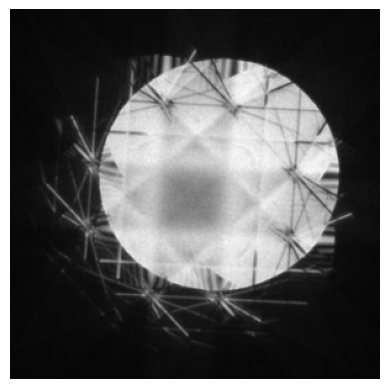

In [44]:
plt.imshow(img.numpy()[0]/255)
plt.axis('off')
plt.show()

In [52]:
preds = predict_and_decode(img, model, labels)
preds

1/1 [==============================] - 0s 47ms/step


{'a': 1.4905652403831482,
 'b': 7.065512090921402,
 't': 165.74746310710907,
 'm': 'Si'}